# CNN profunda

Notebook del Ejercicio 4. Carga los mismos datos preprocesados que `cnn_simple.ipynb` y entrena una segunda arquitectura, más profunda: 4 bloques de convolución (32, 64, 128, 256 filtros) con batch normalization y más dropout, buscando capturar mejor los detalles finos que distinguen letras parecidas (por ejemplo el grupo U/V/R/W/X que salió como el más confuso en el heatmap de similitud del EDA).

In [1]:
from pathlib import Path

import numpy as np

DATA_PATH = Path("asl-alphabet/processed/asl_64x64_600pc.npz")
assert DATA_PATH.exists(), f"No se encontró {DATA_PATH}. Corre primero preprocesamiento.ipynb"

data = np.load(DATA_PATH, allow_pickle=True)

X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
class_names = data["class_names"]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Clases:", list(class_names))
print("Dtype de X:", X_train.dtype, "— rango:", X_train.min(), "-", X_train.max())

Train: (12180, 64, 64, 3) (12180,)
Val:   (2610, 64, 64, 3) (2610,)
Test:  (2610, 64, 64, 3) (2610,)
Clases: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('del'), np.str_('nothing'), np.str_('space')]
Dtype de X: uint8 — rango: 0 - 255


## Normalización

In [2]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

NUM_CLASSES = len(class_names)
IMG_SIZE = X_train.shape[1]

print(f"Imagenes de {IMG_SIZE}x{IMG_SIZE}, {NUM_CLASSES} clases")

Imagenes de 64x64, 29 clases


## Arquitectura

4 bloques de convolución (32, 64, 128, 256 filtros), cada uno con batch normalization antes de la activación y max pooling después. Dropout más agresivo antes de la capa de salida para compensar la mayor cantidad de parámetros.

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    return x

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = conv_block(inputs, 32)
x = conv_block(x, 64)
x = conv_block(x, 128)
x = conv_block(x, 256)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# Con batch normalization en una red tan profunda, el learning rate por
# defecto de Adam (1e-3) es demasiado alto: el modelo no logra bajar del
# accuracy de azar. Con 3e-4 converge de forma estable.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,446,141 (5.52 MB)

 Trainable params: 1,445,181 (5.51 MB)

 Non-trainable params: 960 (3.75 KB)

## Entrenamiento

In [4]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/25


  1/191 ━━━━━━━━━━━━━━━━━━━━ 2:23 754ms/step - accuracy: 0.0312 - loss: 4.7458

  2/191 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.0625 - loss: 4.4635  

  3/191 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.0625 - loss: 4.5365

  4/191 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.0703 - loss: 4.4261

...

187/191 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9652 - loss: 0.1037

188/191 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9650 - loss: 0.1041

189/191 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9651 - loss: 0.1040

190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9652 - loss: 0.1037

191/191 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.9653 - loss: 0.1036 - val_accuracy: 0.8854 - val_loss: 0.3829


## Curvas de entrenamiento

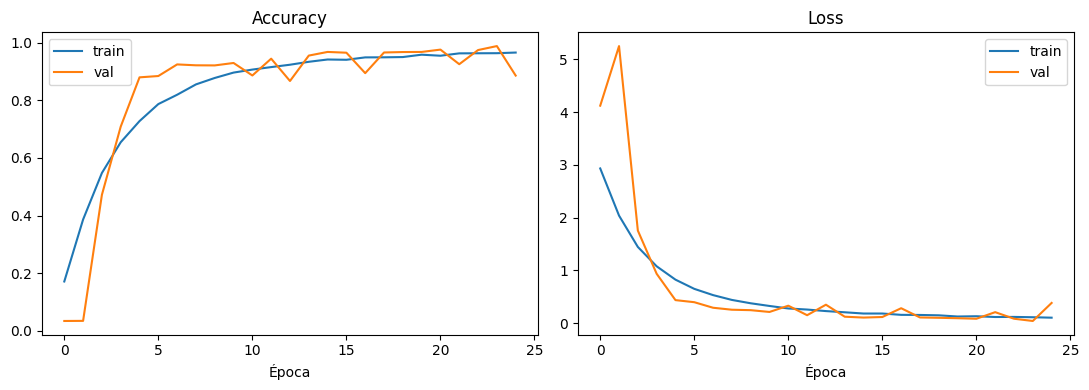

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluación en test

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy en test: {test_acc:.4f}")
print(f"Loss en test: {test_loss:.4f}")

Accuracy en test: 0.9866
Loss en test: 0.0432


In [7]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           A       0.98      0.98      0.98        90
           B       0.98      0.99      0.98        90
           C       1.00      1.00      1.00        90
           D       1.00      0.93      0.97        90
           E       0.98      0.98      0.98        90
           F       0.99      1.00      0.99        90
           G       0.99      0.99      0.99        90
           H       0.99      0.98      0.98        90
           I       1.00      0.99      0.99        90
           J       0.97      1.00      0.98        90
           K       0.98      0.99      0.98        90
           L       1.00      1.00      1.00        90
           M       0.91      1.00      0.95        90
           N       1.00      0.98      0.99        90
           O       1.00      0.94      0.97        90
           P       1.00      1.00      1.00        90
           Q       1.00      1.00      1.00        90
           R       1.00    

## Matriz de confusión

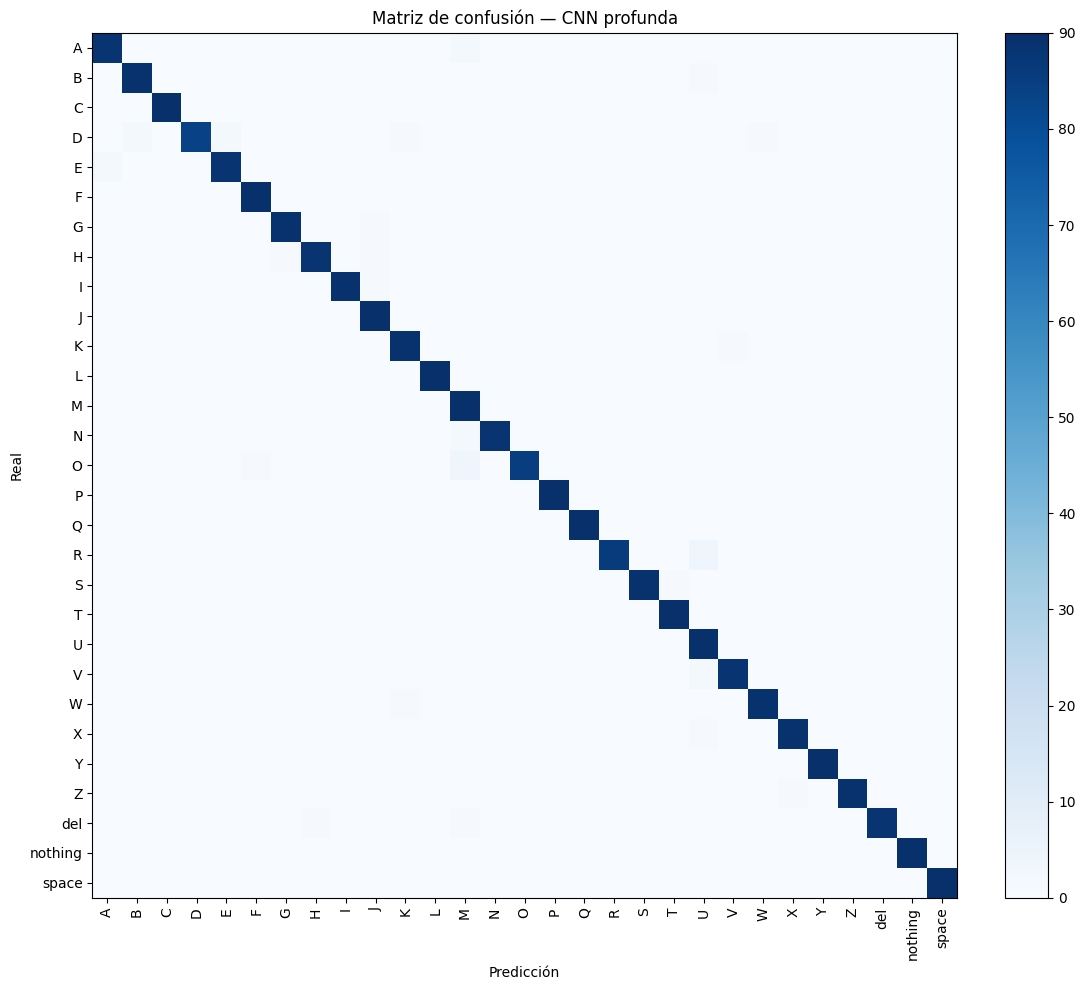

In [8]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=90)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — CNN profunda")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Guardar el modelo

Se guarda para poder compararlo contra la CNN simple y para probarlo más adelante con fotos propias (Ejercicio 8).

In [9]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

model.save(MODELS_DIR / "cnn_profunda.keras")
print("Modelo guardado en", (MODELS_DIR / "cnn_profunda.keras").resolve())

Modelo guardado en /Users/nilsmurallesmorales/universidad/octavosemestre/data/lab3/models/cnn_profunda.keras
